# Simulazione della Dosi nella mama

## Import


In [1]:
import spekpy as sp
import numpy as np
import matplotlib.pyplot as plt
import os

## 1. Generazione spettri

### 25kvp


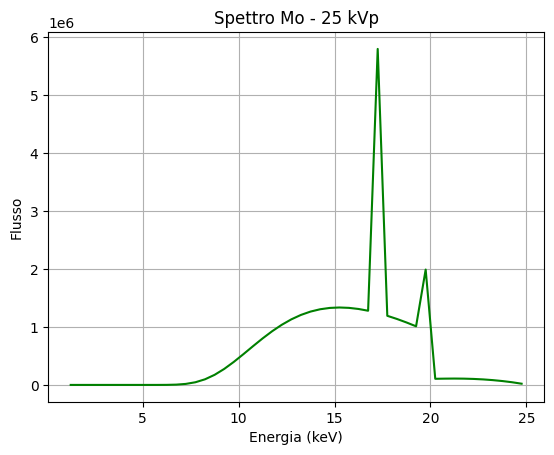

In [28]:
# Configurazione spettro 25 kVp
s = sp.Spek(kvp=25, targ='Mo', th=10)
s.filter('Mo', 0.03) 
energy, flux = s.get_spectrum(edges=False)

# Salvataggio per PENMAIN (Energia in eV)
np.savetxt('spettro_25kvp.dat', 
           np.column_stack((energy * 1000, flux)),
           fmt='%.4E')

# Plot
plt.plot(energy, flux, color='green')
plt.title("Spettro Mo - 25 kVp")
plt.xlabel("Energia (keV)"); plt.ylabel("Flusso"); plt.grid(True)
plt.show()

### 28kvp

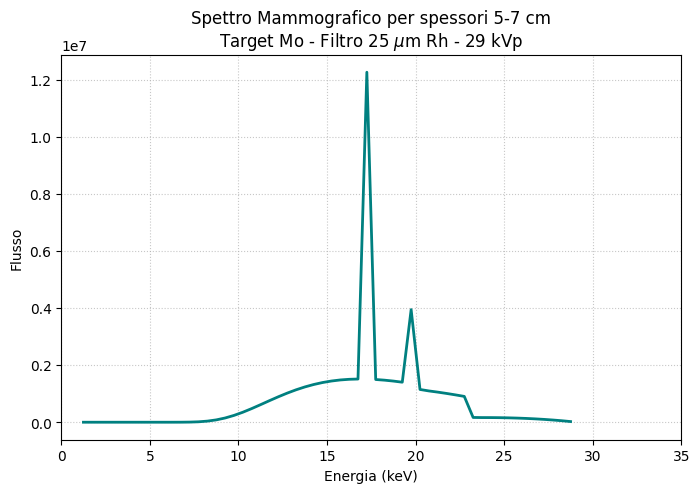

In [25]:
# --- Configurazione spettro Mammografia (Spessori 5-7 cm) ---
kvp_selected = 29 
s = sp.Spek(kvp=kvp_selected, targ='Mo', th=10)

# FILTRAZIONE: 25 um di Rodio (Rh) -> 0.025 mm
s.filter('Rh', 0.025) 

# Ottenimento spettro
energy, flux = s.get_spectrum(edges=False)

# Salvataggio per PENMAIN
np.savetxt('spettro_29kvp_Rh.dat', np.column_stack((energy * 1000, flux)), fmt='%.4E')

# Plot dello spettro
plt.figure(figsize=(8, 5))
plt.plot(energy, flux, color='teal', lw=2)

# Nota la 'r' prima delle virgolette per evitare il SyntaxWarning
plt.title(fr"Spettro Mammografico per spessori 5-7 cm" + "\n" + fr"Target Mo - Filtro 25 $\mu$m Rh - {kvp_selected} kVp")

plt.xlabel("Energia (keV)")
plt.ylabel("Flusso")
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0, 35)
plt.show()

### 30kvp


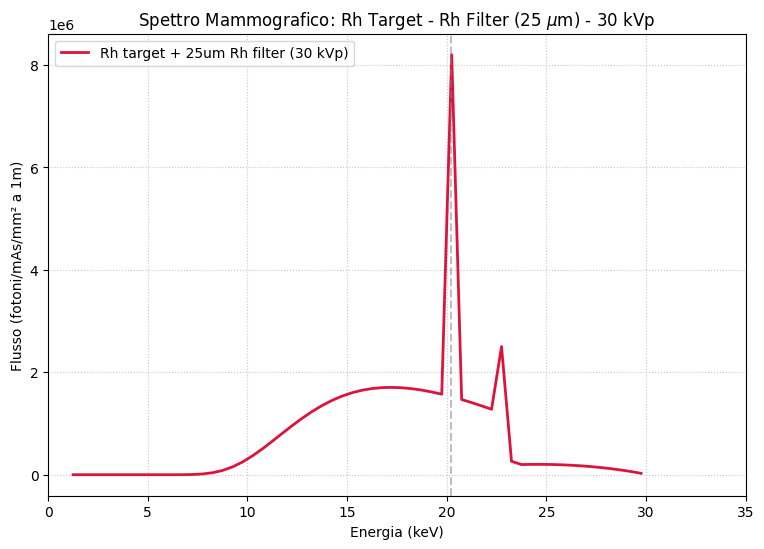

File 'spettro_30kvp_RhRh.dat' generato con successo.


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import spekpy as sp

# --- Configurazione spettro Mammografia (Consegna Rh/Rh) ---
# kvp=30: Tensione richiesta
# targ='Rh': Anodo di RODIO
# th=10: Angolo dell'anodo tipico
kvp_selected = 30 
s = sp.Spek(kvp=kvp_selected, targ='Rh', th=10)

# FILTRAZIONE: 25 um di Rodio (Rh) -> 0.025 mm
s.filter('Rh', 0.025) 

# Ottenimento spettro (edges=False per array stessa lunghezza)
energy, flux = s.get_spectrum(edges=False)

# --- Salvataggio per PENMAIN (Energia in eV) ---
# Il file viene salvato con i valori di energia in eV e il flusso relativo
np.savetxt('spettro_30kvp_RhRh.dat', np.column_stack((energy * 1000, flux)), fmt='%.4E')

# --- Plot dello spettro ---
plt.figure(figsize=(9, 6))
plt.plot(energy, flux, color='crimson', lw=2, label=f'Rh target + 25um Rh filter (30 kVp)')

# Titolo con Raw String per evitare SyntaxWarning sul simbolo micro
plt.title(fr"Spettro Mammografico: Rh Target - Rh Filter (25 $\mu$m) - 30 kVp")
plt.xlabel("Energia (keV)")
plt.ylabel("Flusso (fotoni/mAs/mm² a 1m)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0, 35)

# Evidenziamo dove cadono le righe caratteristiche del Rodio (K-alpha ~20.2 keV)
plt.axvline(x=20.2, color='gray', linestyle='--', alpha=0.5, label='Rh K-alpha')

plt.show()

print(f"File 'spettro_30kvp_RhRh.dat' generato con successo.")

## 2. Calcolo della Dose assoluta


In [4]:
# Parametri fisici
corrente_mA = 100.0
tempo_s = 1.0
mAs = corrente_mA * tempo_s 

altezza_cm = 5.0 
raggio_cm = 8.0 
volume_cm3 = np.pi * (raggio_cm**2) * altezza_cm 

# Densità glandular 50% (dalla tabella PDF)
densita_50 = 0.98190 # g/cm^3 
massa_g = volume_cm3 * densita_50
massa_kg = massa_g / 1000.0

print(f"Volume Mammella: {volume_cm3:.2f} cm^3")
print(f"Massa Mammella (50%): {massa_kg:.4f} kg")

Volume Mammella: 1005.31 cm^3
Massa Mammella (50%): 0.9871 kg


## 3. Analisi Distribuzione in Profondità (Punto 2 e 3)

In [5]:
def carica_dose(filename, densita):
    # Esempio di caricamento dati da PENELOPE
    # data = np.loadtxt(filename)
    # prof = data[:, 0] # Profondità z
    # dose_eV_per_e = data[:, 1] # Energia depositata
    
    # Conversione in Gray (J/kg)
    # 1 eV = 1.602e-19 J
    # Ricorda di moltiplicare per il numero reale di elettroni (basato sui mAs)
    pass